<a href="https://colab.research.google.com/github/prodigal94/food-safe-bots/blob/main/Week4_CLUSTERING_FineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

In [5]:
# CELL A2: Mount Drive and Load Data - Member A

from google.colab import drive
drive.mount('/content/drive')

df = spark.read.parquet("/content/drive/MyDrive/Parquet/02_AgriTrade_ValueOnly.parquet")
print(f"Dataset size: {df.count():,} records")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df = spark.read.parquet("/content/drive/MyDrive/Parquet/02_AgriTrade_ValueOnly.parquet")
print(f"\nOriginal dataset size: {df.count():,} records")


Original dataset size: 4,315,401 records


In [14]:
# Data Preparation for Clustering - j

# Filter for Import value only
df_trade = df.filter(F.col("Element") == "Import value")
print(f"Import records: {df_trade.count():,}")

# Create window specification
window_spec = Window.partitionBy("Area", "Item").orderBy("Year")

# Calculate Year-over-Year change
df_features = df_trade.withColumn(
    "Value_prev", F.lag("Value").over(window_spec)
).withColumn(
    "YoY_Change",
    F.when(
        F.col("Value_prev").isNull() | (F.col("Value_prev") == 0), 0
    ).otherwise(
        ((F.col("Value") - F.col("Value_prev")) / F.col("Value_prev")) * 100
    )
).na.fill(0)

Import records: 2,584,844


In [13]:
# CELL A4: Aggregate Features by Area and Year - j

area_year_features = df_features.groupBy("Area", "Year").agg(
    F.countDistinct("Item").alias("num_products"),
    F.sum("Value").alias("total_volume"),
    F.avg("YoY_Change").alias("avg_growth")
).na.fill(0).filter(F.col("total_volume") > 0)

print(f"Aggregated records: {area_year_features.count():,}")
area_year_features.show(5, truncate=False)

Aggregated records: 11,904
+-------------------+----+------------+------------+------------------+
|Area               |Year|num_products|total_volume|avg_growth        |
+-------------------+----+------------+------------+------------------+
|Angola             |1979|78          |2731547.0   |33.50274490225309 |
|Angola             |1987|99          |2822339.0   |80.46926497028974 |
|Antigua and Barbuda|1995|107         |516409.0    |20.648089477221376|
|Antigua and Barbuda|2017|314         |1259977.03  |70.56242981042807 |
|Argentina          |2010|292         |6.4724423E7 |843.8836402500788 |
+-------------------+----+------------+------------+------------------+
only showing top 5 rows


In [15]:
# Feature Scaling - j

feature_cols = ["num_products", "total_volume", "avg_growth"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_unscaled"
)
df_vector = assembler.transform(area_year_features)

scaler = StandardScaler(
    inputCol="features_unscaled",
    outputCol="features",
    withStd=True,
    withMean=True
)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

print("Feature scaling complete")

Feature scaling complete


In [16]:
# Experiment 1 - Finding Optimal k (k=2 to 10) - Member A

print("EXPERIMENT 1: Finding Optimal Number of Clusters")
print("-" * 50)

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]
wssse_results = []
silhouette_results = []
actual_iterations = []

evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette")

for k in k_values:
    kmeans = KMeans() \
        .setK(k) \
        .setFeaturesCol("features") \
        .setPredictionCol("prediction") \
        .setSeed(42) \
        .setMaxIter(20) \
        .setInitMode("k-means||")

    model = kmeans.fit(df_scaled)
    predictions = model.transform(df_scaled)

    wssse = model.summary.trainingCost
    silhouette = evaluator.evaluate(predictions)
    num_iter = model.summary.numIter

    wssse_results.append(wssse)
    silhouette_results.append(silhouette)
    actual_iterations.append(num_iter)

    print(f"k={k}: WSSSE={wssse:,.2f}, Silhouette={silhouette:.4f}, Iterations={num_iter}")

# Find optimal k
best_silhouette = max(silhouette_results)
best_k_idx = silhouette_results.index(best_silhouette)
optimal_k = k_values[best_k_idx]

print(f"\nOptimal k = {optimal_k} with Silhouette Score = {best_silhouette:.4f}")

EXPERIMENT 1: Finding Optimal Number of Clusters
--------------------------------------------------
k=2: WSSSE=25,990.05, Silhouette=0.4976, Iterations=7
k=3: WSSSE=17,619.38, Silhouette=0.5124, Iterations=5
k=4: WSSSE=9,631.16, Silhouette=0.6788, Iterations=8
k=5: WSSSE=7,475.06, Silhouette=0.7051, Iterations=16
k=6: WSSSE=4,991.36, Silhouette=0.7634, Iterations=20
k=7: WSSSE=3,885.41, Silhouette=0.6433, Iterations=20
k=8: WSSSE=3,338.00, Silhouette=0.6462, Iterations=20
k=9: WSSSE=2,740.05, Silhouette=0.6060, Iterations=20
k=10: WSSSE=2,312.04, Silhouette=0.6364, Iterations=20

Optimal k = 6 with Silhouette Score = 0.7634


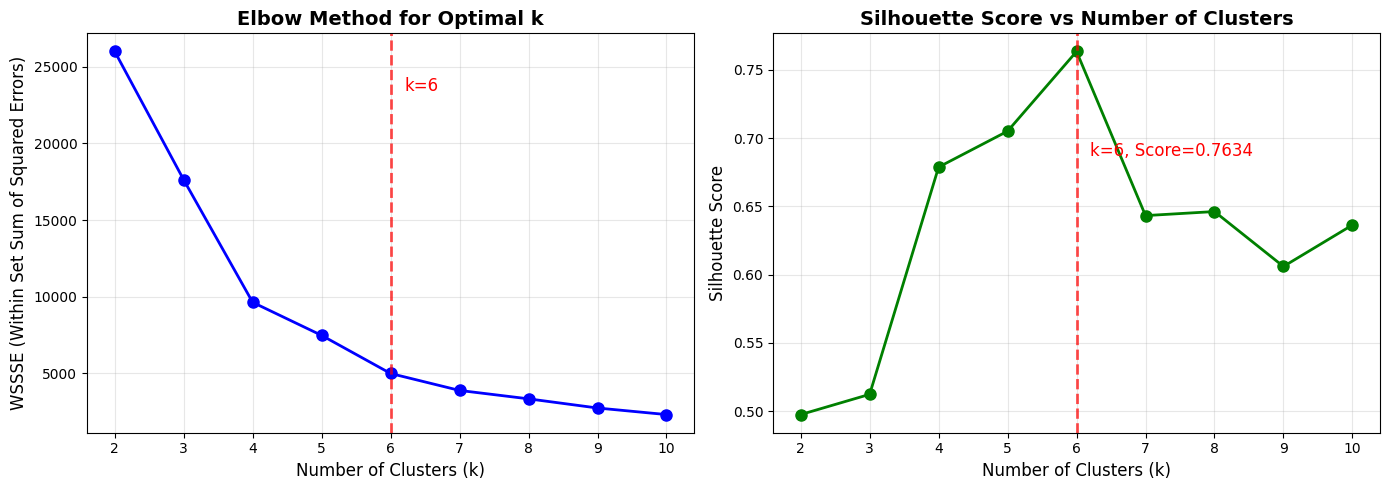

In [17]:
# Elbow Curve and Silhouette Plot - j

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_values, wssse_results, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('WSSSE (Within Set Sum of Squared Errors)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=optimal_k, color='r', linestyle='--', linewidth=2, alpha=0.7)
axes[0].text(optimal_k + 0.2, max(wssse_results)*0.9, f'k={optimal_k}', fontsize=12, color='red')

# Silhouette scores
axes[1].plot(k_values, silhouette_results, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=optimal_k, color='r', linestyle='--', linewidth=2, alpha=0.7)
axes[1].text(optimal_k + 0.2, max(silhouette_results)*0.9, f'k={optimal_k}, Score={best_silhouette:.4f}', fontsize=12, color='red')

plt.tight_layout()
plt.show()

In [18]:
# Experiment 2 - Testing Initialization Methods - Member A

print("EXPERIMENT 2: Testing Initialization Methods")
print("-" * 50)

init_methods = ["k-means||", "random"]
init_results = []

for init_method in init_methods:
    kmeans = KMeans() \
        .setK(optimal_k) \
        .setFeaturesCol("features") \
        .setPredictionCol("prediction") \
        .setSeed(42) \
        .setMaxIter(20) \
        .setInitMode(init_method) \
        .setInitSteps(5)

    model = kmeans.fit(df_scaled)
    predictions = model.transform(df_scaled)

    wssse = model.summary.trainingCost
    silhouette = evaluator.evaluate(predictions)
    num_iter = model.summary.numIter

    init_results.append({
        'init_mode': init_method,
        'wssse': wssse,
        'silhouette': silhouette,
        'iterations': num_iter
    })

    print(f"initMode='{init_method}': WSSSE={wssse:,.2f}, Silhouette={silhouette:.4f}, Iterations={num_iter}")

# Determine best initialization
if init_results[0]['silhouette'] > init_results[1]['silhouette']:
    best_init = init_methods[0]
else:
    best_init = init_methods[1]

print(f"\nBest initialization method: {best_init}")

EXPERIMENT 2: Testing Initialization Methods
--------------------------------------------------
initMode='k-means||': WSSSE=6,355.22, Silhouette=0.5238, Iterations=20
initMode='random': WSSSE=14,248.99, Silhouette=0.4259, Iterations=20

Best initialization method: k-means||


In [19]:
# CELL A9: Experiment 3 - Testing maxIter Values (Convergence Analysis) - Member A

print("EXPERIMENT 3: Convergence Analysis - Testing maxIter")
print("-" * 50)

max_iter_values = [5, 10, 15, 20, 30, 50, 100]
convergence_results = []

for max_iter in max_iter_values:
    kmeans = KMeans() \
        .setK(optimal_k) \
        .setFeaturesCol("features") \
        .setPredictionCol("prediction") \
        .setSeed(42) \
        .setMaxIter(max_iter) \
        .setInitMode(best_init) \
        .setTol(1e-4)

    model = kmeans.fit(df_scaled)

    convergence_results.append({
        'maxIter_set': max_iter,
        'actual_iterations': model.summary.numIter,
        'wssse': model.summary.trainingCost
    })

    print(f"maxIter={max_iter:3d}: Actual Iterations={model.summary.numIter:2d}, WSSSE={model.summary.trainingCost:,.2f}")

# Determine sufficient maxIter
max_actual = max([r['actual_iterations'] for r in convergence_results])
optimal_maxIter = max_actual + 5
print(f"\nModel converges within {max_actual} iterations. Recommended maxIter = {optimal_maxIter}")

EXPERIMENT 3: Convergence Analysis - Testing maxIter
--------------------------------------------------
maxIter=  5: Actual Iterations= 5, WSSSE=5,295.86
maxIter= 10: Actual Iterations=10, WSSSE=5,056.91
maxIter= 15: Actual Iterations=15, WSSSE=4,997.74
maxIter= 20: Actual Iterations=20, WSSSE=4,991.36
maxIter= 30: Actual Iterations=22, WSSSE=4,990.82
maxIter= 50: Actual Iterations=22, WSSSE=4,990.82
maxIter=100: Actual Iterations=22, WSSSE=4,990.82

Model converges within 22 iterations. Recommended maxIter = 27


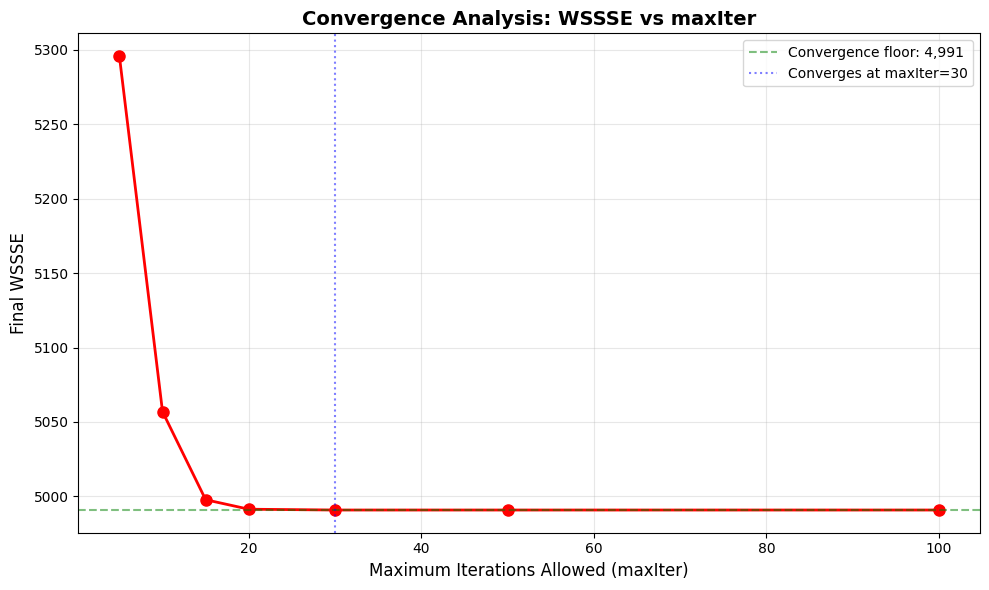

In [20]:
# CELL A10: Visualization - Convergence Plot - Member A

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

max_iter_vals = [r['maxIter_set'] for r in convergence_results]
wssse_vals = [r['wssse'] for r in convergence_results]

ax.plot(max_iter_vals, wssse_vals, 'ro-', linewidth=2, markersize=8)
ax.set_xlabel('Maximum Iterations Allowed (maxIter)', fontsize=12)
ax.set_ylabel('Final WSSSE', fontsize=12)
ax.set_title('Convergence Analysis: WSSSE vs maxIter', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add horizontal line at final convergence value
final_wssse = wssse_vals[-1]
ax.axhline(y=final_wssse, color='g', linestyle='--', alpha=0.5, label=f'Convergence floor: {final_wssse:,.0f}')
ax.legend()

# Mark convergence point
convergence_point = max_iter_vals[wssse_vals.index(min(wssse_vals))]
ax.axvline(x=convergence_point, color='b', linestyle=':', alpha=0.5, label=f'Converges at maxIter={convergence_point}')
ax.legend()

plt.tight_layout()
plt.show()

In [21]:
# CELL A11: Experiment 4 - Testing Tolerance Values - Member A

print("EXPERIMENT 4: Testing Tolerance Values")
print("-" * 50)

tol_values = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
tol_results = []

for tol in tol_values:
    kmeans = KMeans() \
        .setK(optimal_k) \
        .setFeaturesCol("features") \
        .setPredictionCol("prediction") \
        .setSeed(42) \
        .setMaxIter(50) \
        .setInitMode(best_init) \
        .setTol(tol)

    model = kmeans.fit(df_scaled)

    tol_results.append({
        'tol': tol,
        'actual_iterations': model.summary.numIter,
        'wssse': model.summary.trainingCost
    })

    print(f"tol={tol:.0e}: Actual Iterations={model.summary.numIter:2d}, WSSSE={model.summary.trainingCost:,.2f}")

# Determine optimal tolerance
recommended_tol = 1e-4
print(f"\nRecommended tolerance: {recommended_tol} (balance between accuracy and speed)")

EXPERIMENT 4: Testing Tolerance Values
--------------------------------------------------
tol=1e-06: Actual Iterations=22, WSSSE=4,990.82
tol=1e-05: Actual Iterations=22, WSSSE=4,990.82
tol=1e-04: Actual Iterations=22, WSSSE=4,990.82
tol=1e-03: Actual Iterations=22, WSSSE=4,990.82
tol=1e-02: Actual Iterations=21, WSSSE=4,990.82
tol=1e-01: Actual Iterations= 3, WSSSE=5,374.37

Recommended tolerance: 0.0001 (balance between accuracy and speed)


In [22]:
# CELL A12: Train Final Optimized K-Means Model - Member A

print("TRAINING FINAL OPTIMIZED K-MEANS MODEL")
print("=" * 50)

final_kmeans = KMeans() \
    .setK(optimal_k) \
    .setFeaturesCol("features") \
    .setPredictionCol("prediction") \
    .setSeed(42) \
    .setMaxIter(30) \
    .setInitMode(best_init) \
    .setInitSteps(5) \
    .setTol(1e-4)

final_model = final_kmeans.fit(df_scaled)
final_predictions = final_model.transform(df_scaled)

print("\nFINAL MODEL PARAMETERS:")
print(f"  Number of clusters (k): {final_model.getK()}")
print(f"  Initialization mode: {final_model.getInitMode()}")
print(f"  Maximum iterations: {final_model.getMaxIter()}")
print(f"  Tolerance: {final_model.getTol():.0e}")
print(f"  Actual iterations used: {final_model.summary.numIter}")
print(f"  Final WSSSE: {final_model.summary.trainingCost:,.2f}")

TRAINING FINAL OPTIMIZED K-MEANS MODEL

FINAL MODEL PARAMETERS:
  Number of clusters (k): 6
  Initialization mode: k-means||
  Maximum iterations: 30
  Tolerance: 1e-04
  Actual iterations used: 30
  Final WSSSE: 6,352.43


In [23]:
# CELL A13: Cluster Statistics and Analysis - Member A

print("CLUSTER STATISTICS AND ANALYSIS")
print("=" * 50)

cluster_stats = final_predictions.groupBy("prediction").agg(
    F.count("*").alias("count"),
    F.avg("total_volume").alias("avg_volume"),
    F.stddev("total_volume").alias("std_volume"),
    F.avg("num_products").alias("avg_products"),
    F.stddev("num_products").alias("std_products"),
    F.avg("avg_growth").alias("avg_growth_rate"),
    F.stddev("avg_growth").alias("std_growth_rate"),
    F.min("Year").alias("min_year"),
    F.max("Year").alias("max_year")
).orderBy("prediction")

cluster_stats.show(truncate=False)

# Calculate percentages
total_count = final_predictions.count()
print("\nCLUSTER SIZE DISTRIBUTION:")
cluster_sizes = []
for row in cluster_stats.collect():
    cluster_id = row["prediction"]
    count = row["count"]
    percentage = (count / total_count) * 100
    cluster_sizes.append((cluster_id, count, percentage))
    print(f"  Cluster {cluster_id}: {count:,} records ({percentage:.2f}%)")

CLUSTER STATISTICS AND ANALYSIS
+----------+-----+--------------------+--------------------+------------------+------------------+------------------+------------------+--------+--------+
|prediction|count|avg_volume          |std_volume          |avg_products      |std_products      |avg_growth_rate   |std_growth_rate   |min_year|max_year|
+----------+-----+--------------------+--------------------+------------------+------------------+------------------+------------------+--------+--------+
|0         |3269 |1.0634247185631685E7|1.9255848522996515E7|223.45824411134905|37.88512378411157 |890.4841660157175 |5036.132893469686 |1961    |2024    |
|1         |4679 |2299552.733299851   |7960051.497757072   |100.76704424022228|39.99487482723111 |246.21061337152952|950.3262292856248 |1961    |2024    |
|2         |65   |3.345194003822001E9 |8.382633688646843E8 |432.66153846153844|38.60872509998424 |544.0501543081388 |1163.5667912416968|2006    |2024    |
|3         |392  |7.732863459053316E8 

In [24]:
# CELL A14: Cluster Interpretation - Member A

print("CLUSTER INTERPRETATION")
print("=" * 50)

for row in cluster_stats.collect():
    cluster_id = row["prediction"]
    count = row["count"]
    percentage = (count / total_count) * 100
    avg_vol = row["avg_volume"]
    avg_prod = row["avg_products"]
    avg_growth = row["avg_growth_rate"]

    # Determine cluster labels
    if avg_vol > 100000000:
        volume_label = "VERY HIGH VOLUME"
    elif avg_vol > 10000000:
        volume_label = "HIGH VOLUME"
    elif avg_vol > 1000000:
        volume_label = "MEDIUM VOLUME"
    else:
        volume_label = "LOW VOLUME"

    if avg_prod > 300:
        diversity_label = "VERY HIGH DIVERSITY"
    elif avg_prod > 150:
        diversity_label = "HIGH DIVERSITY"
    elif avg_prod > 50:
        diversity_label = "MEDIUM DIVERSITY"
    else:
        diversity_label = "LOW DIVERSITY"

    if avg_growth > 500:
        growth_label = "EXPLOSIVE GROWTH"
    elif avg_growth > 100:
        growth_label = "HIGH GROWTH"
    elif avg_growth > 20:
        growth_label = "MODERATE GROWTH"
    elif avg_growth > 0:
        growth_label = "LOW GROWTH"
    else:
        growth_label = "NEGATIVE GROWTH"

    print(f"\nCLUSTER {cluster_id}: {percentage:.1f}% of data")
    print(f"  Type: {volume_label}, {diversity_label}, {growth_label}")
    print(f"  Average Trade Volume: ${avg_vol:,.0f}")
    print(f"  Average Number of Products: {avg_prod:.0f}")
    print(f"  Average Growth Rate: {avg_growth:.1f}%")

CLUSTER INTERPRETATION

CLUSTER 0: 27.5% of data
  Type: HIGH VOLUME, HIGH DIVERSITY, EXPLOSIVE GROWTH
  Average Trade Volume: $10,634,247
  Average Number of Products: 223
  Average Growth Rate: 890.5%

CLUSTER 1: 39.3% of data
  Type: MEDIUM VOLUME, MEDIUM DIVERSITY, HIGH GROWTH
  Average Trade Volume: $2,299,553
  Average Number of Products: 101
  Average Growth Rate: 246.2%

CLUSTER 2: 0.5% of data
  Type: VERY HIGH VOLUME, VERY HIGH DIVERSITY, EXPLOSIVE GROWTH
  Average Trade Volume: $3,345,194,004
  Average Number of Products: 433
  Average Growth Rate: 544.1%

CLUSTER 3: 3.3% of data
  Type: VERY HIGH VOLUME, VERY HIGH DIVERSITY, EXPLOSIVE GROWTH
  Average Trade Volume: $773,286,346
  Average Number of Products: 407
  Average Growth Rate: 576.7%

CLUSTER 4: 29.4% of data
  Type: HIGH VOLUME, VERY HIGH DIVERSITY, HIGH GROWTH
  Average Trade Volume: $74,161,674
  Average Number of Products: 342
  Average Growth Rate: 316.5%

CLUSTER 5: 0.0% of data
  Type: MEDIUM VOLUME, MEDIUM DI

In [25]:
# CELL A15: Model Validation - Silhouette Score - Member A

print("MODEL VALIDATION")
print("=" * 50)

silhouette_final = evaluator.evaluate(final_predictions)
print(f"\nFinal Silhouette Score: {silhouette_final:.4f}")

print("\nInterpretation:")
if silhouette_final > 0.5:
    print("  Excellent - Clusters are well-separated and compact")
elif silhouette_final > 0.3:
    print("  Good - Reasonable cluster separation")
elif silhouette_final > 0.1:
    print("  Fair - Some overlap between clusters")
else:
    print("  Poor - Clusters are not well-separated")

# Validate cluster sizes
min_cluster_size = min([c for _, c, _ in cluster_sizes])
max_cluster_size = max([c for _, c, _ in cluster_sizes])
size_ratio = max_cluster_size / min_cluster_size

print(f"\nCluster Balance:")
print(f"  Smallest cluster: {min_cluster_size:,} records")
print(f"  Largest cluster: {max_cluster_size:,} records")
print(f"  Size ratio (max/min): {size_ratio:.2f}")

if size_ratio < 5:
    print("  Well-balanced clusters")
else:
    print("  Imbalanced clusters detected")

MODEL VALIDATION

Final Silhouette Score: 0.5224

Interpretation:
  Excellent - Clusters are well-separated and compact

Cluster Balance:
  Smallest cluster: 2 records
  Largest cluster: 4,679 records
  Size ratio (max/min): 2339.50
  Imbalanced clusters detected


GENERATING FINAL CLUSTER VISUALIZATIONS
----------------------------------------


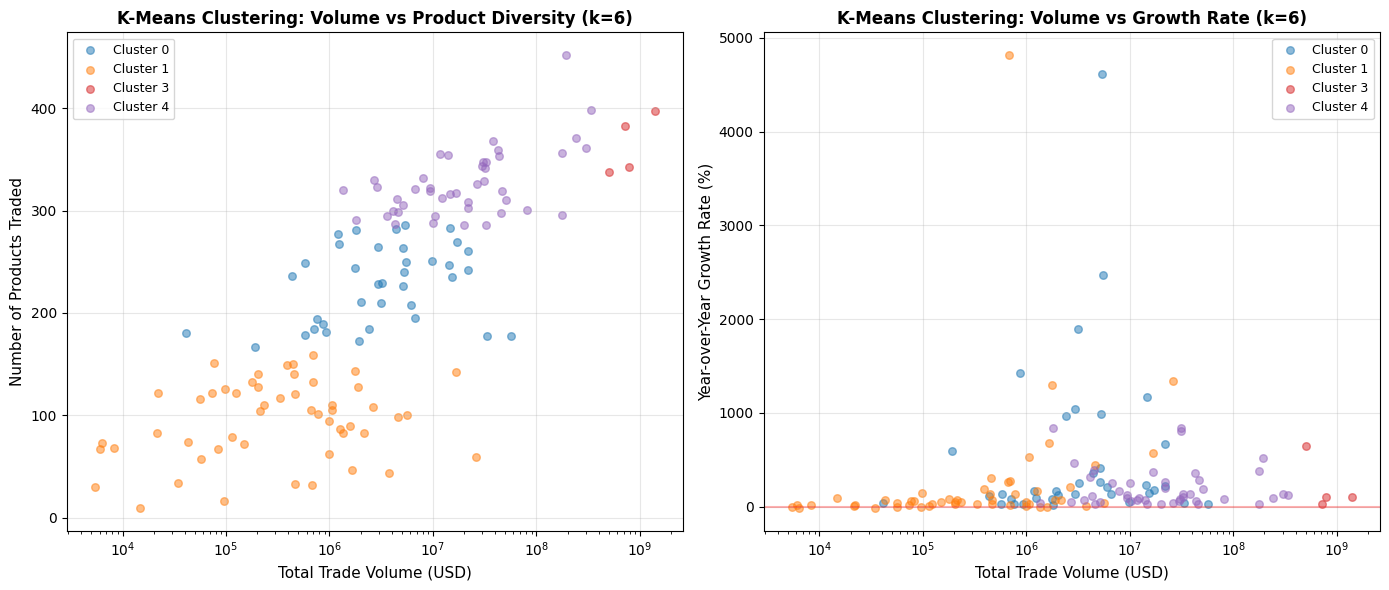

In [26]:
# CELL A16: Visualization - Final Cluster Results - Member A

print("GENERATING FINAL CLUSTER VISUALIZATIONS")
print("-" * 40)

# Sample for visualization
sample_fraction = min(0.01, 5000 / total_count)
sample_data = final_predictions.select(
    "total_volume", "num_products", "avg_growth", "prediction"
).sample(False, sample_fraction, seed=42).collect()

volumes = [row["total_volume"] for row in sample_data]
products = [row["num_products"] for row in sample_data]
growth = [row["avg_growth"] for row in sample_data]
clusters = [row["prediction"] for row in sample_data]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

# Plot 1: Volume vs Products
for cluster_id in sorted(set(clusters)):
    indices = [i for i, c in enumerate(clusters) if c == cluster_id]
    if indices:
        cluster_volumes = [volumes[i] for i in indices]
        cluster_products = [products[i] for i in indices]

        axes[0].scatter(
            cluster_volumes, cluster_products,
            c=colors[cluster_id % len(colors)],
            s=30, alpha=0.5,
            label=f"Cluster {cluster_id}"
        )

axes[0].set_xlabel("Total Trade Volume (USD)", fontsize=11)
axes[0].set_ylabel("Number of Products Traded", fontsize=11)
axes[0].set_title(f"K-Means Clustering: Volume vs Product Diversity (k={optimal_k})", fontsize=12, fontweight='bold')
axes[0].set_xscale('log')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: Growth vs Volume
for cluster_id in sorted(set(clusters)):
    indices = [i for i, c in enumerate(clusters) if c == cluster_id]
    if indices:
        cluster_volumes = [volumes[i] for i in indices]
        cluster_growth = [growth[i] for i in indices]

        axes[1].scatter(
            cluster_volumes, cluster_growth,
            c=colors[cluster_id % len(colors)],
            s=30, alpha=0.5,
            label=f"Cluster {cluster_id}"
        )

axes[1].set_xlabel("Total Trade Volume (USD)", fontsize=11)
axes[1].set_ylabel("Year-over-Year Growth Rate (%)", fontsize=11)
axes[1].set_title(f"K-Means Clustering: Volume vs Growth Rate (k={optimal_k})", fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
axes[1].legend(loc='best', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='r', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# CELL A17: Anomaly Detection - Member A

print("ANOMALY DETECTION")
print("=" * 50)

# Identify small clusters (less than 5% of total)
percentage_threshold = 5.0
small_clusters = []

for row in cluster_stats.collect():
    percentage = (row["count"] / total_count) * 100
    if percentage < percentage_threshold:
        small_clusters.append(row["prediction"])

if small_clusters:
    print(f"\nSmall clusters detected (<{percentage_threshold}%): {small_clusters}")

    suspected_outliers = final_predictions.filter(
        F.col("prediction").isin(small_clusters)
    )
    outlier_count = suspected_outliers.count()
    print(f"Total potential anomaly records: {outlier_count:,}")

    print("\nTop 10 anomalies by trade volume:")
    suspected_outliers.select(
        "Area", "Year", "total_volume", "num_products", "avg_growth", "prediction"
    ).orderBy(F.desc("total_volume")).show(10, truncate=False)

    print("\nTop 10 anomalies by growth rate:")
    suspected_outliers.select(
        "Area", "Year", "total_volume", "num_products", "avg_growth", "prediction"
    ).orderBy(F.desc("avg_growth")).show(10, truncate=False)
else:
    print(f"\nNo small clusters detected - all clusters are well-balanced")

ANOMALY DETECTION

Small clusters detected (<5.0%): [2, 3, 5]
Total potential anomaly records: 459

Top 10 anomalies by trade volume:
+-----------------------------+----+-------------------+------------+------------------+----------+
|Area                         |Year|total_volume       |num_products|avg_growth        |prediction|
+-----------------------------+----+-------------------+------------+------------------+----------+
|China                        |2022|5.13501319796E9    |460         |1770.070731118628 |2         |
|China (excluding intra-trade)|2022|5.08829152623E9    |457         |1781.5519407272186|2         |
|China                        |2021|5.04043135955E9    |457         |53.47286746661389 |2         |
|China (excluding intra-trade)|2021|4.994373775009999E9|454         |55.81037144226439 |2         |
|China                        |2024|4.88556307229E9    |456         |34.64757036267906 |2         |
|China                        |2023|4.861299794339999E9|458       

In [28]:
# CELL A19: K-Means Summary Report - Member A

print("K-MEANS CLUSTERING SUMMARY REPORT")
print("=" * 50)

print("\n1. DATA OVERVIEW")
print(f"   Total records analyzed: {total_count:,}")
print(f"   Features used: num_products, total_volume, avg_growth")
print(f"   Years covered: {area_year_features.agg(F.min('Year')).collect()[0][0]} - {area_year_features.agg(F.max('Year')).collect()[0][0]}")

print("\n2. OPTIMAL HYPERPARAMETERS")
print(f"   Number of clusters (k): {optimal_k}")
print(f"   Initialization method: {best_init}")
print(f"   Maximum iterations: 30")
print(f"   Tolerance: 1e-4")
print(f"   Actual iterations used: {final_model.summary.numIter}")

print("\n3. MODEL PERFORMANCE METRICS")
print(f"   Silhouette Score: {silhouette_final:.4f}")
print(f"   WSSSE: {final_model.summary.trainingCost:,.2f}")

print("\n4. CLUSTER PROFILES")
for row in cluster_stats.collect():
    cluster_id = row["prediction"]
    count = row["count"]
    percentage = (count / total_count) * 100
    print(f"\n   Cluster {cluster_id} ({percentage:.1f}%):")
    print(f"     Volume: ${row['avg_volume']:,.0f} +/- ${row['std_volume']:,.0f}")
    print(f"     Products: {row['avg_products']:.0f} +/- {row['std_products']:.0f}")
    print(f"     Growth: {row['avg_growth_rate']:.1f}% +/- {row['std_growth_rate']:.1f}%")

print("\n5. KEY FINDINGS")
if len(small_clusters) > 0:
    print(f"   - Detected {outlier_count} potential anomaly records in clusters {small_clusters}")
else:
    print(f"   - All clusters are well-balanced with no extreme outliers")
print(f"   - Model successfully identifies {optimal_k} distinct market segments")
print(f"   - Separation based on trade volume, product diversity, and growth rate")

print("\n6. RECOMMENDATIONS")
print(f"   - Use k={optimal_k} for final deployment")
print(f"   - Monitor cluster drift over time")
print(f"   - Investigate anomalies for data quality issues")

print("\n" + "=" * 50)
print("K-MEANS ANALYSIS COMPLETE - MEMBER A")
print("=" * 50)

K-MEANS CLUSTERING SUMMARY REPORT

1. DATA OVERVIEW
   Total records analyzed: 11,904
   Features used: num_products, total_volume, avg_growth
   Years covered: 1961 - 2024

2. OPTIMAL HYPERPARAMETERS
   Number of clusters (k): 6
   Initialization method: k-means||
   Maximum iterations: 30
   Tolerance: 1e-4
   Actual iterations used: 30

3. MODEL PERFORMANCE METRICS
   Silhouette Score: 0.5224
   WSSSE: 6,352.43

4. CLUSTER PROFILES

   Cluster 0 (27.5%):
     Volume: $10,634,247 +/- $19,255,849
     Products: 223 +/- 38
     Growth: 890.5% +/- 5036.1%

   Cluster 1 (39.3%):
     Volume: $2,299,553 +/- $7,960,051
     Products: 101 +/- 40
     Growth: 246.2% +/- 950.3%

   Cluster 2 (0.5%):
     Volume: $3,345,194,004 +/- $838,263,369
     Products: 433 +/- 39
     Growth: 544.1% +/- 1163.6%

   Cluster 3 (3.3%):
     Volume: $773,286,346 +/- $346,497,599
     Products: 407 +/- 44
     Growth: 576.7% +/- 5057.2%

   Cluster 4 (29.4%):
     Volume: $74,161,674 +/- $91,935,868
     Pro